<a href="https://colab.research.google.com/github/CharuSoni13/dip_lab/blob/main/EXP7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving image1.jpg to image1.jpg


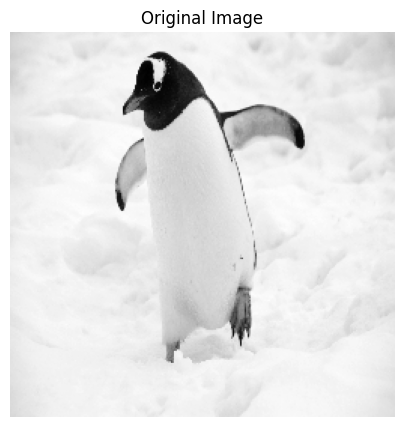

Sample Huffman Codes:
Pixel Value 202: 0000
Pixel Value 203: 0100
Pixel Value 204: 1001
Pixel Value 205: 1011
Pixel Value 206: 1000
Pixel Value 207: 0101
Pixel Value 208: 0010
Pixel Value 195: 00010
Pixel Value 196: 00111
Pixel Value 197: 01100


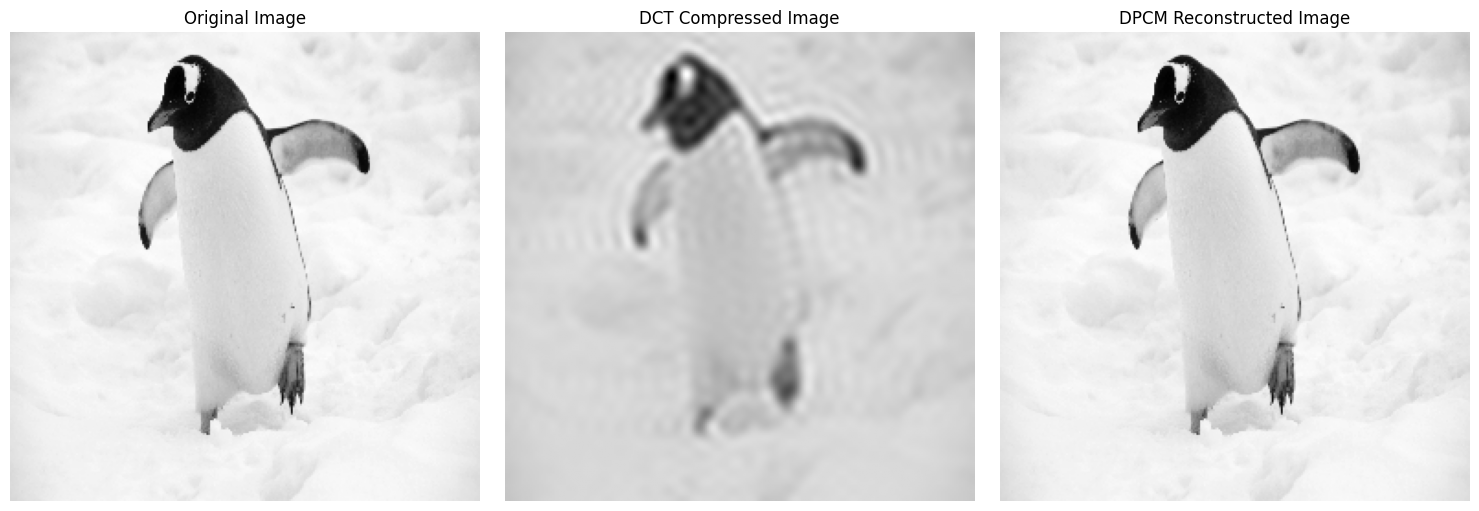

In [ ]:
# ==========================================================
# Image Compression using DCT, DPCM and Huffman Coding
# ==========================================================

# Install OpenCV
!pip install opencv-python

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from collections import Counter
import heapq

# ==========================================================
# STEP 1: Upload Image at Runtime
# ==========================================================

uploaded = files.upload()

# Get uploaded image name automatically
image_name = list(uploaded.keys())[0]

# Read image in grayscale
img = cv2.imread(image_name, 0)

# Resize image for easy processing
img = cv2.resize(img, (256,256))

# ==========================================================
# STEP 2: Display Original Image
# ==========================================================

plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

# ==========================================================
# STEP 3: DCT Compression
# ==========================================================

# Convert image to float32
img_float = np.float32(img)

# Apply DCT
dct = cv2.dct(img_float)

# Keep only low-frequency coefficients
dct_compressed = np.zeros_like(dct)

dct_compressed[:50, :50] = dct[:50, :50]

# Apply inverse DCT
reconstructed_dct = cv2.idct(dct_compressed)

# ==========================================================
# STEP 4: DPCM Compression
# ==========================================================

# Create DPCM image
dpcm = np.zeros_like(img, dtype=np.int16)

# First pixel remains same
dpcm[:,0] = img[:,0]

# Difference coding
for i in range(img.shape[0]):
    for j in range(1, img.shape[1]):
        dpcm[i,j] = int(img[i,j]) - int(img[i,j-1])

# Reconstruct image from DPCM
reconstructed_dpcm = np.zeros_like(img, dtype=np.int16)

reconstructed_dpcm[:,0] = dpcm[:,0]

for i in range(img.shape[0]):
    for j in range(1, img.shape[1]):
        reconstructed_dpcm[i,j] = reconstructed_dpcm[i,j-1] + dpcm[i,j]

reconstructed_dpcm = np.clip(reconstructed_dpcm,0,255).astype(np.uint8)

# ==========================================================
# STEP 5: Huffman Coding
# ==========================================================

# Flatten image
pixels = img.flatten()

# Frequency count
frequency = Counter(pixels)

# Build Huffman Tree
heap = [[weight, [symbol, ""]] for symbol, weight in frequency.items()]
heapq.heapify(heap)

while len(heap) > 1:
    low = heapq.heappop(heap)
    high = heapq.heappop(heap)

    for pair in low[1:]:
        pair[1] = '0' + pair[1]

    for pair in high[1:]:
        pair[1] = '1' + pair[1]

    heapq.heappush(heap, [low[0] + high[0]] + low[1:] + high[1:])

# Huffman codes
huffman_codes = sorted(heapq.heappop(heap)[1:], key=lambda p: (len(p[-1]), p))

# Display few Huffman codes
print("Sample Huffman Codes:")
for symbol, code in huffman_codes[:10]:
    print(f"Pixel Value {symbol}: {code}")

# ==========================================================
# STEP 6: Display Results
# ==========================================================

plt.figure(figsize=(15,5))

# Original Image
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

# DCT Reconstructed Image
plt.subplot(1,3,2)
plt.imshow(reconstructed_dct, cmap='gray')
plt.title("DCT Compressed Image")
plt.axis("off")

# DPCM Reconstructed Image
plt.subplot(1,3,3)
plt.imshow(reconstructed_dpcm, cmap='gray')
plt.title("DPCM Reconstructed Image")
plt.axis("off")

plt.tight_layout()
plt.show()